In [7]:
import pandas as pd
df = pd.read_csv('df_ps.csv')
df.sort_values('age')

,user_id,platform,region,age,onboarding_completed,levels_passed
17324,848075,android,tier1,-8.0,1,29
46926,380874,pc,tier2,-3.0,0,16
1101,423538,pc,tier2,-2.0,1,27
43583,297616,android,tier1,-1.0,1,26
14780,794662,android,tier2,1.0,0,15
...,...,...,...,...,...,...
13684,990828,ios,tier1,61.0,1,23
9885,17289,ios,tier1,62.0,0,15
24964,998092,android,tier1,62.0,0,5
44743,962788,ios,tier3,62.0,0,13


In [8]:
import statsmodels.formula.api as smf

# Считаем Propensity Score через логистическую регрессию
ps_model = smf.logit(
    'onboarding_completed ~ age + C(region) + C(platform)',
    data=df
).fit()

# Предсказываем PS для каждого пользователя
df['propensity_score'] = ps_model.predict(df)

# Среднее значение PS
print(round(df['propensity_score'].mean(), 1))

Optimization terminated successfully.
         Current function value: 0.600235
         Iterations 5
0.6


In [9]:
# Бинарное предсказание: 1 если PS >= 0.5, иначе 0
df['ps_pred'] = (df['propensity_score'] >= 0.5).astype(int)

# Accuracy = доля правильных предсказаний
accuracy = (df['ps_pred'] == df['onboarding_completed']).mean()
print(round(accuracy, 2))

0.68


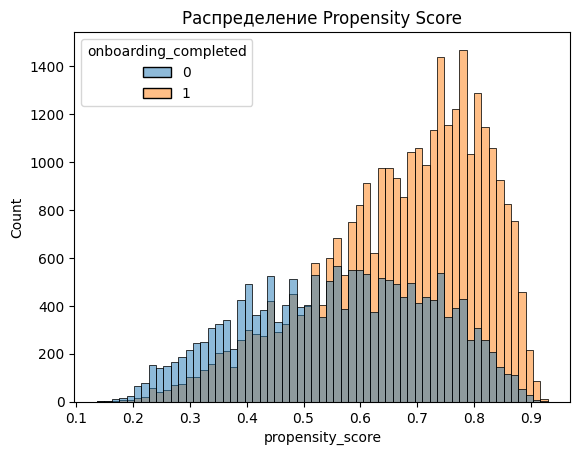

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.title('Распределение Propensity Score')
sns.histplot(data=df, x='propensity_score', hue='onboarding_completed')
plt.show()

onboarding_completed          0          1
ps_bin                                    
(0.136, 0.335]        35.653319  34.801333
(0.335, 0.4]          33.762774  34.250247
(0.4, 0.445]          31.703472  31.570605
(0.445, 0.485]        31.573810  31.163810
(0.485, 0.524]        31.609831  31.568429
(0.524, 0.555]        31.494633  31.623770
(0.555, 0.582]        32.759259  33.065585
(0.582, 0.609]        30.859855  30.373479
(0.609, 0.631]        29.972806  29.737740
(0.631, 0.656]        30.245392  30.164612
(0.656, 0.68]         28.939815  28.955623
(0.68, 0.701]         30.494937  30.530435
(0.701, 0.723]        30.683356  30.860669
(0.723, 0.744]        29.894886  29.431925
(0.744, 0.764]        29.386228  29.305160
(0.764, 0.781]        27.035857  27.672783
(0.781, 0.802]        27.491054  27.881253
(0.802, 0.825]        27.164147  26.955765
(0.825, 0.855]        27.521197  27.431019
(0.855, 0.93]         21.833333  21.396291


/var/folders/6r/hytlw2sn1fs_9jzjy_lsxtg80000gn/T/ipykernel_2888/2846894413.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(['ps_bin', 'onboarding_completed'])['age'] \


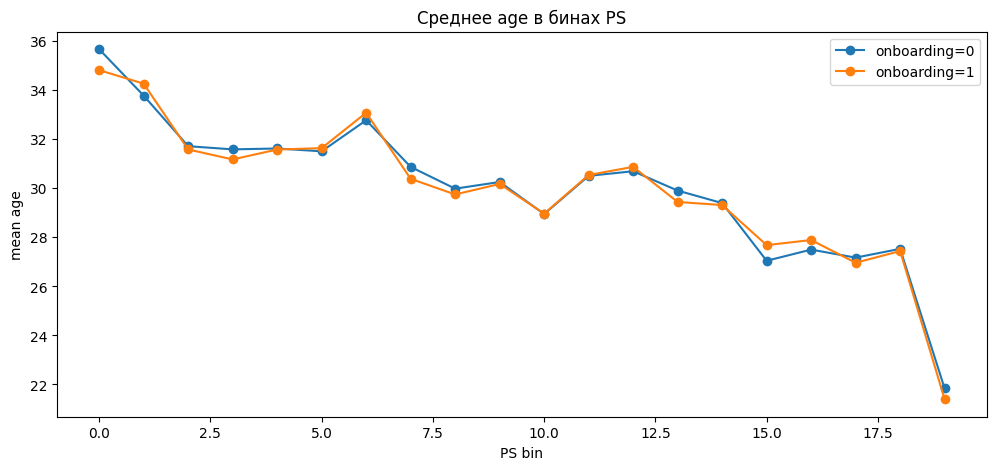

In [11]:
# Нарезаем PS на 20 бинов
df['ps_bin'] = pd.qcut(df['propensity_score'], q=20)

# Считаем среднее age по бинам и группам
grouped = df.groupby(['ps_bin', 'onboarding_completed'])['age'] \
    .mean() \
    .reset_index() \
    .pivot(index='ps_bin', columns='onboarding_completed', values='age') \
    .sort_index()

print(grouped)

# Строим график
plt.figure(figsize=(12, 5))
for col in grouped.columns:
    plt.plot(range(len(grouped)), grouped[col], marker='o', label=f'onboarding={col}')
plt.xlabel('PS bin')
plt.ylabel('mean age')
plt.title('Среднее age в бинах PS')
plt.legend()
plt.show()

In [12]:
model = smf.ols(
    'levels_passed ~ onboarding_completed + propensity_score',
    data=df
).fit()

ate = model.params['onboarding_completed']
print('Оценка эффекта онбординга:', round(ate, 1))
print('Истинный эффект:', 7)

Оценка эффекта онбординга: 7.0
Истинный эффект: 7


In [15]:
import numpy as np
df['weight'] = np.where(
    df['onboarding_completed'] == 1,
    1 / df['propensity_score'],          # для T=1
    1 / (1 - df['propensity_score'])     # для T=0
)
df

,user_id,platform,region,age,onboarding_completed,levels_passed,propensity_score,ps_pred,ps_bin,weight
0,245487,android,tier2,33.0,1,17,0.578913,1,"(0.555, 0.582]",1.727374
1,147916,android,tier2,36.0,1,17,0.555983,1,"(0.555, 0.582]",1.798615
2,740659,android,tier2,32.0,1,30,0.586487,1,"(0.582, 0.609]",1.705069
3,854907,ios,tier1,35.0,1,32,0.825363,1,"(0.802, 0.825]",1.211588
4,819644,pc,tier3,18.0,1,27,0.362395,0,"(0.335, 0.4]",2.759420
...,...,...,...,...,...,...,...,...,...,...
49995,849958,android,tier3,33.0,0,12,0.446649,0,"(0.445, 0.485]",1.807171
49996,854588,ios,tier1,29.0,1,31,0.850686,1,"(0.825, 0.855]",1.175522
49997,428563,ios,tier3,38.0,0,21,0.604984,1,"(0.582, 0.609]",2.531540
49998,824319,android,tier1,44.0,0,15,0.616940,1,"(0.609, 0.631]",2.610554


In [16]:
y1 = np.average(
    df[df['onboarding_completed'] == 1]['levels_passed'],
    weights=df[df['onboarding_completed'] == 1]['weight']
)

y0 = np.average(
    df[df['onboarding_completed'] == 0]['levels_passed'],
    weights=df[df['onboarding_completed'] == 0]['weight']
)

In [19]:
ate_iptw = y1 - y0
print('IPTW оценка ATE:', round(ate_iptw, 1))
print('Истинный ATE:', 7)

IPTW оценка ATE: 7.0
Истинный ATE: 7


In [20]:
print('ATE по OLS:', round(ate, 1))

ATE по OLS: 7.0


In [25]:
import statsmodels.formula.api as smf
import numpy as np

def get_ipw_ate(df, t, y, ps_formula):
    # Шаг 1: считаем PS
    ps_model = smf.logit(ps_formula, data=df).fit(disp=0)
    ps = ps_model.predict(df)
    
    # Шаг 2: считаем E[Y(1)] и E[Y(0)] по формулам
    N = len(df)
    T = df[t].values
    Y = df[y].values
    
    ey1 = (1/N) * np.sum(T * Y / ps)
    ey0 = (1/N) * np.sum((1 - T) * Y / (1 - ps))
    
    # Шаг 3: ATE
    ate = ey1 - ey0
    return ate

# Применяем
ate_ipw = get_ipw_ate(
    df=df,
    t='onboarding_completed',
    y='levels_passed',
    ps_formula='onboarding_completed ~ age + region + platform'
)

print(round(ate_ipw, 3))

7.054


In [26]:
import numpy as np

# Bootstrap для IPTW
np.random.seed(42)
n_bootstrap = 1000
ate_bootstrap = []

for _ in range(n_bootstrap):
    # Сэмплируем с возвращением
    df_boot = df.sample(n=len(df), replace=True)
    ate_boot = get_ipw_ate(
        df=df_boot,
        t='onboarding_completed',
        y='levels_passed',
        ps_formula='onboarding_completed ~ age + C(region) + C(platform)'
    )
    ate_bootstrap.append(ate_boot)

# 95% ДИ для IPTW
ci_lower_ipw = np.percentile(ate_bootstrap, 2.5)
ci_upper_ipw = np.percentile(ate_bootstrap, 97.5)
print(f'IPTW ДИ: [{round(ci_lower_ipw, 3)}, {round(ci_upper_ipw, 3)}]')

# 95% ДИ для OLS
ols_model = smf.ols(
    'levels_passed ~ onboarding_completed + propensity_score',
    data=df
).fit()
ci_ols = ols_model.conf_int().loc['onboarding_completed']
print(f'OLS ДИ: [{round(ci_ols[0], 3)}, {round(ci_ols[1], 3)}]')

# Проверяем захватывают ли ДИ истинный эффект = 7
print('IPTW захватывает 7:', ci_lower_ipw <= 7 <= ci_upper_ipw)
print('OLS захватывает 7:', ci_ols[0] <= 7 <= ci_ols[1])

IPTW ДИ: [6.938, 7.185]
OLS ДИ: [6.899, 7.094]
IPTW захватывает 7: True
OLS захватывает 7: True


In [27]:
import statsmodels.formula.api as smf

features = 'age + C(region) + C(platform)'

# Модель 1: обучаем на контроле (T=0) → предсказывает Y(0)
model_0 = smf.ols(
    f'levels_passed ~ {features}',
    data=df[df['onboarding_completed'] == 0]
).fit()

# Модель 2: обучаем на пилоте (T=1) → предсказывает Y(1)
model_1 = smf.ols(
    f'levels_passed ~ {features}',
    data=df[df['onboarding_completed'] == 1]
).fit()

# Предсказания на ВСЕХ объектах
df['mu0'] = model_0.predict(df)
df['mu1'] = model_1.predict(df)

# ATE = среднее Y(1) - среднее Y(0)
ate_outcome = df['mu1'].mean() - df['mu0'].mean()
print(round(ate_outcome, 2))

6.99


In [28]:
df

,user_id,platform,region,age,onboarding_completed,levels_passed,propensity_score,ps_pred,ps_bin,weight,mu0,mu1
0,245487,android,tier2,33.0,1,17,0.578913,1,"(0.555, 0.582]",1.727374,15.425561,22.422055
1,147916,android,tier2,36.0,1,17,0.555983,1,"(0.555, 0.582]",1.798615,14.814400,21.835705
2,740659,android,tier2,32.0,1,30,0.586487,1,"(0.582, 0.609]",1.705069,15.629281,22.617505
3,854907,ios,tier1,35.0,1,32,0.825363,1,"(0.802, 0.825]",1.211588,21.898708,28.965464
4,819644,pc,tier3,18.0,1,27,0.362395,0,"(0.335, 0.4]",2.759420,11.483735,18.353210
...,...,...,...,...,...,...,...,...,...,...,...,...
49995,849958,android,tier3,33.0,0,12,0.446649,0,"(0.445, 0.485]",1.807171,12.409879,19.370108
49996,854588,ios,tier1,29.0,1,31,0.850686,1,"(0.825, 0.855]",1.175522,23.121029,30.138164
49997,428563,ios,tier3,38.0,0,21,0.604984,1,"(0.582, 0.609]",2.531540,15.357208,22.380417
49998,824319,android,tier1,44.0,0,15,0.616940,1,"(0.609, 0.631]",2.610554,16.099295,23.218853


In [29]:
import statsmodels.formula.api as smf
import numpy as np

def get_doubly_robust_effect(df, ps_formula, outcome_formula, t, y):
    
    # Шаг 1: PS модель
    ps_model = smf.logit(ps_formula, data=df).fit(disp=0)
    ps = ps_model.predict(df)
    
    # Шаг 2: разделяем на пилот и контроль
    df_pilot = df[df[t] == 1]
    df_control = df[df[t] == 0]
    
    # Шаг 3: outcome модели
    g1_model = smf.ols(outcome_formula, data=df_pilot).fit()
    g0_model = smf.ols(outcome_formula, data=df_control).fit()
    
    # Шаг 4: предсказания на всех объектах
    y1_g = g1_model.predict(df)
    y0_g = g0_model.predict(df)
    
    T = df[t].values
    Y = df[y].values
    N = len(df)
    
    # Шаг 5: E[Y(1)]
    ey1 = (1/N) * np.sum(T * (Y - y1_g) / ps + y1_g)
    
    # Шаг 6: E[Y(0)]
    ey0 = (1/N) * np.sum((1 - T) * (Y - y0_g) / (1 - ps) + y0_g)
    
    # Шаг 7: ATE
    return ey1 - ey0

# Вызываем функцию
ate_dr = get_doubly_robust_effect(
    df,
    'onboarding_completed ~ age + C(region) + C(platform)',
    'levels_passed ~ age + C(region) + C(platform)',
    'onboarding_completed',
    'levels_passed'
)

print(round(ate_dr, 3))

6.986


In [31]:
def get_doubly_robust_effect_random_ps(df, ps_formula, outcome_formula, t, y):
    
    # Убираем seed — каждый раз разные PS
    ps = np.random.uniform(0, 1, size=len(df))
    
    df_pilot = df[df[t] == 1]
    df_control = df[df[t] == 0]
    
    g1_model = smf.ols(outcome_formula, data=df_pilot).fit()
    g0_model = smf.ols(outcome_formula, data=df_control).fit()
    
    y1_g = g1_model.predict(df)
    y0_g = g0_model.predict(df)
    
    T = df[t].values
    Y = df[y].values
    N = len(df)
    
    ey1 = (1/N) * np.sum(T * (Y - y1_g) / ps + y1_g)
    ey0 = (1/N) * np.sum((1-T) * (Y - y0_g) / (1-ps) + y0_g)
    
    return ey1 - ey0

# Bootstrap
ate_list = []
for _ in range(1000):
    df_boot = df.sample(n=len(df), replace=True)
    ate_boot = get_doubly_robust_effect_random_ps(
        df_boot,
        'onboarding_completed ~ age + C(region) + C(platform)',
        'levels_passed ~ age + C(region) + C(platform)',
        'onboarding_completed',
        'levels_passed'
    )
    ate_list.append(ate_boot)

ci_lower = np.percentile(ate_list, 2.5)
ci_upper = np.percentile(ate_list, 97.5)
print(f'ATE: {round(np.mean(ate_list), 3)}')
print(f'ДИ: [{round(ci_lower, 3)}, {round(ci_upper, 3)}]')
print(f'Захватывает 7: {ci_lower <= 7 <= ci_upper}')

ATE: 23.746
ДИ: [-67.569, 91.685]
Захватывает 7: True
